In [0]:
# Databricks notebook source
# MAGIC %md
# MAGIC # NOTEBOOK 06 : MLFLOW - MODEL REGISTRY & PRODUCTION
# MAGIC 
# MAGIC **Objectif** : Enregistrer le meilleur modèle du Notebook 05 dans MLflow Model Registry et le mettre en Production
# MAGIC **Pré-requis** : Notebook 05_Modeling_Baseline.ipynb exécuté avec succès
# MAGIC **Contenu** :
# MAGIC - Récupération des runs MLflow existants (du Notebook 05)
# MAGIC - Identification du meilleur modèle
# MAGIC - Enregistrement dans Model Registry
# MAGIC - Transition vers Production
# MAGIC - Ajout de métadonnées et tags
# MAGIC **Note importante** : Ce notebook NE RÉENTRAÎNE PAS les modèles. Il utilise ceux déjà loggés dans le Notebook 05.
# CELLULE 1 : IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# MLflow
import mlflow
from mlflow.tracking import MlflowClient
from pyspark.sql import functions as F
print("="*70)
print("IMPORTS RÉUSSIS")
print("="*70)
print(f"Date : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f" MLflow Version : {mlflow.__version__}")
print("="*70)

IMPORTS RÉUSSIS
Date : 2025-12-22 12:43:31
🤖 MLflow Version : 2.22.0


In [0]:
# CELLULE DE DIAGNOSTIC : Lister tous les experiments existants
print("="*70)
print(" LISTE DE TOUS LES EXPERIMENTS EXISTANTS")
print("="*70)

import mlflow
from mlflow.tracking import MlflowClient

client = MlflowClient()

# Lister tous les experiments
all_experiments = client.search_experiments()

if len(all_experiments) == 0:
    print("\nAucun experiment trouvé dans le workspace")
else:
    print(f"\n{len(all_experiments)} experiment(s) trouvé(s) :\n")
    print(f"{'Nom de l\'Experiment':<60} {'ID':<10} {'Nb Runs'}")
    print("─"*80)
    
    for exp in all_experiments:
        # Compter les runs dans cet experiment
        runs = client.search_runs(experiment_ids=[exp.experiment_id])
        print(f"{exp.name:<60} {exp.experiment_id:<10} {len(runs)}")
    
    print("─"*80)

 LISTE DE TOUS LES EXPERIMENTS EXISTANTS

3 experiment(s) trouvé(s) :

Nom de l'Experiment                                          ID         Nb Runs
────────────────────────────────────────────────────────────────────────────────
/Users/gueyeamdy457@gmail.com/05_modeling_baselineAdvance    2714591848174164 46
/Users/gueyeamdy457@gmail.com/Hospital_Readmission_sklearn   2082003638344431 5
/Users/gueyeamdy457@gmail.com/Hospital_Readmission_Prediction 2040446457752333 2
────────────────────────────────────────────────────────────────────────────────


In [0]:
# MAGIC ## CELLULE 2.1 : INSPECTION DES MÉTRIQUES DISPONIBLES

print("="*70)
print("INSPECTION DES MÉTRIQUES DISPONIBLES DANS LES RUNS")
print("="*70)

# Prendre le premier run comme exemple
if len(runs) > 0:
    sample_run = runs[0]
    print(f"\n Exemple de run : {sample_run.data.tags.get('mlflow.runName', 'Unknown')}")
    print(f"   Run ID : {sample_run.info.run_id}")
    
    print(f"\n Métriques disponibles :")
    print(f"{'─'*50}")
    for metric_name, metric_value in sample_run.data.metrics.items():
        print(f"   {metric_name:<30} : {metric_value:.4f}")
    print(f"{'─'*50}")
    
    print(f"\n Paramètres disponibles :")
    print(f"{'─'*50}")
    for param_name, param_value in sample_run.data.params.items():
        print(f"   {param_name:<30} : {param_value}")
    print(f"{'─'*50}")
    
    print(f"\nTags disponibles :")
    print(f"{'─'*50}")
    for tag_name, tag_value in sample_run.data.tags.items():
        if not tag_name.startswith('mlflow.'):  # Filtrer les tags système MLflow
            print(f"   {tag_name:<30} : {tag_value}")
    print(f"{'─'*50}")

print("="*70)

INSPECTION DES MÉTRIQUES DISPONIBLES DANS LES RUNS

 Exemple de run : Logistic_Regression_Baseline
   Run ID : d7919654ea6746b68b6b4020e8a7f743

 Métriques disponibles :
──────────────────────────────────────────────────
   auc_pr                         : 0.3548
   accuracy                       : 0.7514
   true_positives                 : 8.0000
   true_negatives                 : 10447.0000
   recall_class_positive          : 0.0023
   recall                         : 0.7514
   precision_class_positive       : 0.5333
   precision                      : 0.6974
   false_positives                : 7.0000
   false_negatives                : 3452.0000
   f1_score                       : 0.6458
   f1_class_positive              : 0.0046
   auc_roc                        : 0.6363
──────────────────────────────────────────────────

 Paramètres disponibles :
──────────────────────────────────────────────────
   elasticNetParam                : 0.0
   family                         : binomial

In [0]:
# MAGIC ## CELLULE 2 : RÉCUPÉRATION DES RUNS EXISTANTS

print("="*70)
print(" RÉCUPÉRATION DES RUNS MLflow DU NOTEBOOK 05")
print("="*70)

# Nom de l'experiment (celui créé dans Notebook 05)
experiment_name = "/Users/gueyeamdy457@gmail.com/05_modeling_baselineAdvance"

# Client MLflow
client = MlflowClient()

# Vérifier si l'experiment existe
try:
    experiment = mlflow.get_experiment_by_name(experiment_name)
    if experiment is None:
        print(f"\nERREUR : L'experiment '{experiment_name}' n'existe pas")
        print(f"   → Vérifier que le Notebook 05 a été exécuté")
        print(f"   → Vérifier le nom de l'experiment")
        dbutils.notebook.exit("Experiment not found")
    
    experiment_id = experiment.experiment_id
    print(f"\nExperiment trouvé : {experiment_name}")
    print(f"   Experiment ID : {experiment_id}")
    
except Exception as e:
    print(f"\n❌ ERREUR : {e}")
    dbutils.notebook.exit(f"Error: {e}")

# Récupérer tous les runs de cet experiment
runs = client.search_runs(
    experiment_ids=[experiment_id],
    order_by=["metrics.auc_roc DESC"]  # ← MODIFIÉ : auc_roc au lieu de val_auc
)

print(f"\n Nombre de runs trouvés : {len(runs)}")

if len(runs) == 0:
    print(f"\n ERREUR : Aucun run trouvé dans cet experiment")
    print(f"   → Exécuter le Notebook 05 d'abord pour créer les runs")
    dbutils.notebook.exit("No runs found")

# Afficher les runs
print(f"\n LISTE DES RUNS (triés par AUC-ROC décroissant) :")
print(f"{'─'*110}")
print(f"{'Run Name':<35} {'Run ID':<35} {'AUC-ROC':<10} {'F1':<10} {'Recall':<10}")
print(f"{'─'*110}")

for run in runs[:10]:  # Top 10
    run_name = run.data.tags.get('mlflow.runName', 'Unknown')
    run_id = run.info.run_id
    auc_roc = run.data.metrics.get('auc_roc', 0)  # ← MODIFIÉ
    f1 = run.data.metrics.get('f1', 0)  # ← MODIFIÉ
    recall = run.data.metrics.get('recall', 0)  # ← AJOUTÉ
    
    print(f"{run_name:<35} {run_id:<35} {auc_roc:<10.4f} {f1:<10.4f} {recall:<10.4f}")

print(f"{'─'*110}")
print("="*70)

 RÉCUPÉRATION DES RUNS MLflow DU NOTEBOOK 05

Experiment trouvé : /Users/gueyeamdy457@gmail.com/05_modeling_baselineAdvance
   Experiment ID : 2714591848174164

 Nombre de runs trouvés : 46

 LISTE DES RUNS (triés par AUC-ROC décroissant) :
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Run Name                            Run ID                              AUC-ROC    F1         Recall    
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Best_Model_Logistic Regression      d622801f0fc442aebdb46795caa26b0b    0.6458     0.3994     0.9916    
Model_Logistic Regression           167c5b3495194bdb863cf38405ec55d0    0.6458     0.3994     0.9916    
Best_Model_Logistic Regression      a50f046a14554424935ea1b87ee73d2a    0.6458     0.3994     0.9916    
Model_Logistic Regression           3f8a1f245e714e1e8024514ad54385b3    0.6458     0.3994     0.9916    
Best_Model_L

In [0]:
# MAGIC ## CELLULE 3 : IDENTIFICATION DU MEILLEUR MODÈLE

# COMMAND ----------

print("="*70)
print(" IDENTIFICATION DU MEILLEUR MODÈLE")
print("="*70)

# Le premier run est le meilleur (déjà trié par auc_roc DESC)
best_run = runs[0]

# Extraire informations
best_run_id = best_run.info.run_id
best_run_name = best_run.data.tags.get('mlflow.runName', 'Unknown')
best_auc_roc = best_run.data.metrics.get('auc_roc', 0)  # ← MODIFIÉ
best_auc_pr = best_run.data.metrics.get('auc_pr', 0)  # ← MODIFIÉ
best_f1 = best_run.data.metrics.get('f1', 0)  # ← MODIFIÉ
best_precision = best_run.data.metrics.get('precision', 0)  # ← MODIFIÉ
best_recall = best_run.data.metrics.get('recall', 0)  # ← MODIFIÉ
best_accuracy = best_run.data.metrics.get('accuracy', 0)  # ← AJOUTÉ
best_training_time = best_run.data.metrics.get('training_time', 0)  # ← AJOUTÉ

print(f"\n MEILLEUR MODÈLE SÉLECTIONNÉ")
print(f"{'─'*70}")
print(f"   Nom : {best_run_name}")
print(f"   Run ID : {best_run_id}")
print(f"{'─'*70}")
print(f"   AUC-ROC        : {best_auc_roc:.4f}")
print(f"   AUC-PR         : {best_auc_pr:.4f}")
print(f"   Accuracy       : {best_accuracy:.4f}")
print(f"{'─'*70}")
print(f"   Precision      : {best_precision:.4f}")
print(f"   Recall         : {best_recall:.4f}")
print(f"   F1-Score       : {best_f1:.4f}")
print(f"{'─'*70}")
print(f"   Training Time  : {best_training_time:.2f}s")
print(f"{'─'*70}")

# Vérifier que le modèle a bien été loggé
model_uri = f"runs:/{best_run_id}/model"
try:
    # Tester le chargement
    test_model = mlflow.sklearn.load_model(model_uri)  # ← MODIFIÉ : sklearn au lieu de pyfunc
    print(f"\nModèle trouvé et chargeable")
    print(f"   URI : {model_uri}")
    print(f"   Type : {type(test_model).__name__}")
except Exception as e:
    print(f"\n ERREUR : Le modèle n'a pas pu être chargé")
    print(f"   {e}")
    dbutils.notebook.exit("Model loading error")

print("="*70)

 IDENTIFICATION DU MEILLEUR MODÈLE

 MEILLEUR MODÈLE SÉLECTIONNÉ
──────────────────────────────────────────────────────────────────────
   Nom : Best_Model_Logistic Regression
   Run ID : d622801f0fc442aebdb46795caa26b0b
──────────────────────────────────────────────────────────────────────
   AUC-ROC        : 0.6458
   AUC-PR         : 0.3593
   Accuracy       : 0.2606
──────────────────────────────────────────────────────────────────────
   Precision      : 0.2501
   Recall         : 0.9916
   F1-Score       : 0.3994
──────────────────────────────────────────────────────────────────────
   Training Time  : 0.14s
──────────────────────────────────────────────────────────────────────

Modèle trouvé et chargeable
   URI : runs:/d622801f0fc442aebdb46795caa26b0b/model
   Type : Pipeline


 VISUALISATION COMPARATIVE DES RUNS

Tableau récapitulatif :



,run_name,run_id,auc_roc,auc_pr,f1,precision,recall,accuracy,training_time
0,Best_Model_Logistic Regression,d622801f0fc442aebdb46795caa26b0b,0.6458,0.3593,0.3994,0.2501,0.9916,0.2606,0.14s
1,Model_Logistic Regression,167c5b3495194bdb863cf38405ec55d0,0.6458,0.3593,0.3994,0.2501,0.9916,0.2606,0.14s
2,Best_Model_Logistic Regression,a50f046a14554424935ea1b87ee73d2a,0.6458,0.3593,0.3994,0.2501,0.9916,0.2606,0.49s
3,Model_Logistic Regression,3f8a1f245e714e1e8024514ad54385b3,0.6458,0.3593,0.3994,0.2501,0.9916,0.2606,0.49s
4,Best_Model_Logistic Regression,d19a81255e0449eba7fd77e2d6a2dcc8,0.6458,0.3593,0.3994,0.2501,0.9916,0.2606,0.42s
5,Model_Logistic Regression,6b347afda0954c36bbdba07027c539d7,0.6458,0.3593,0.3994,0.2501,0.9916,0.2606,0.42s
6,Best_Model_Logistic Regression,5c85076e6132417ca4965d0175e64b03,0.6458,0.3593,0.3994,0.2501,0.9916,0.2606,1.42s
7,Model_Logistic Regression,147c09a7e5b04545a1fe59f2c9449129,0.6458,0.3593,0.3994,0.2501,0.9916,0.2606,1.42s
8,Best_Model_Logistic Regression,350d38f048274843a833e22883e3d635,0.6458,0.3593,0.3994,0.2501,0.9916,0.2606,0.85s
9,Model_Logistic Regression,90646a14558f47a3a0851cc31c65e7a9,0.6458,0.3593,0.3994,0.2501,0.9916,0.2606,0.85s


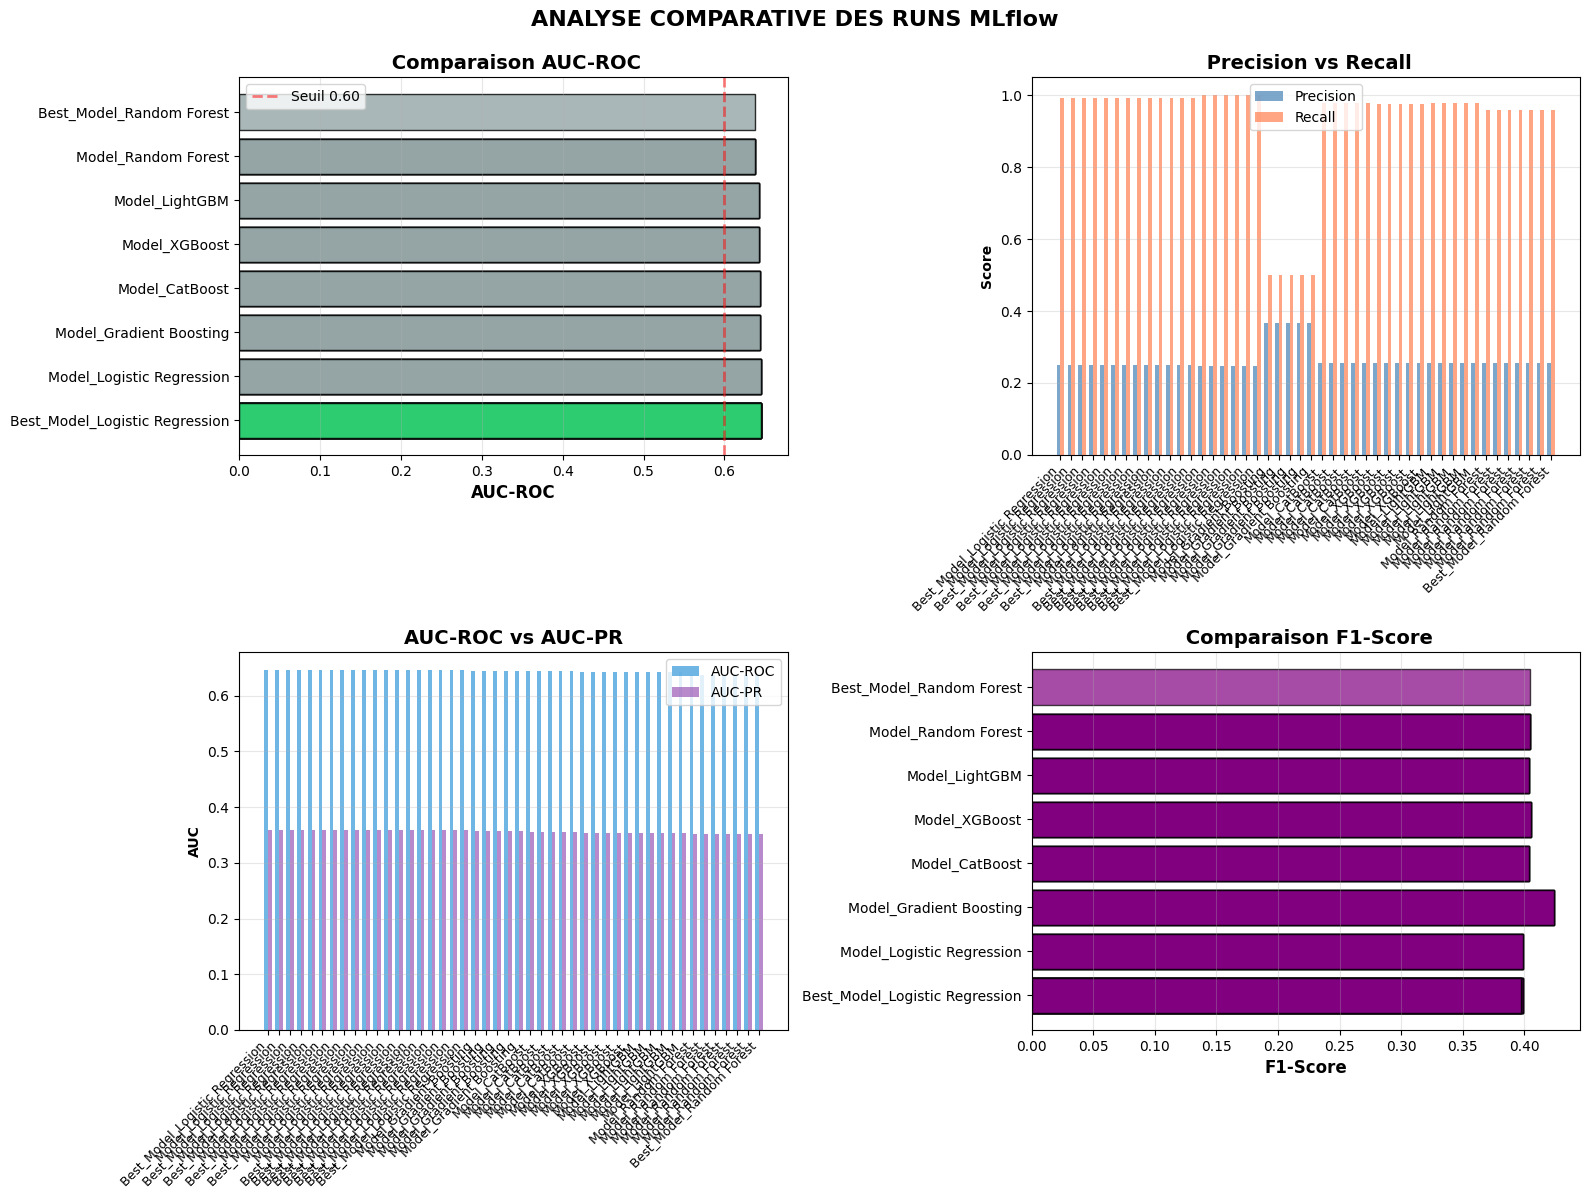


Visualisations sauvegardées : /Volumes/workspace/default/amdy_hopitalisation_data/mlflow/mlflow_runs_comparison.png


In [0]:
# MAGIC %md
# MAGIC ##  CELLULE 4 : COMPARAISON VISUELLE DES RUNS
# COMMAND ----------

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
print("="*70)
print(" VISUALISATION COMPARATIVE DES RUNS")
print("="*70)

# Extraire données de tous les runs
runs_data = []
for run in runs:
    runs_data.append({
        'run_name': run.data.tags.get('mlflow.runName', 'Unknown'),
        'run_id': run.info.run_id,
        'auc_roc': run.data.metrics.get('auc_roc', 0),  
        'auc_pr': run.data.metrics.get('auc_pr', 0), 
        'f1': run.data.metrics.get('f1', 0),  
        'precision': run.data.metrics.get('precision', 0), 
        'recall': run.data.metrics.get('recall', 0),  
        'accuracy': run.data.metrics.get('accuracy', 0),  
        'training_time': run.data.metrics.get('training_time', 0) 
    })
runs_df = pd.DataFrame(runs_data)
print(f"\nTableau récapitulatif :\n")
display(runs_df.head(10).style.format({
    'auc_roc': '{:.4f}',
    'auc_pr': '{:.4f}',
    'f1': '{:.4f}',
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'accuracy': '{:.4f}',
    'training_time': '{:.2f}s'
}).background_gradient(subset=['auc_roc'], cmap='RdYlGn', vmin=0.50, vmax=0.80))
# ========================================
# GRAPHIQUES
# ========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. AUC-ROC Comparison
ax1 = axes[0, 0]
colors = ['#2ecc71' if row['run_name'] == best_run_name else '#95a5a6' 
          for _, row in runs_df.iterrows()]
ax1.barh(runs_df['run_name'], runs_df['auc_roc'], color=colors, alpha=0.8, edgecolor='black')
ax1.set_xlabel('AUC-ROC', fontweight='bold', fontsize=12)
ax1.set_title(' Comparaison AUC-ROC', fontsize=14, fontweight='bold')
ax1.axvline(0.60, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Seuil 0.60')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='x')
# 2. Precision vs Recall
ax2 = axes[0, 1]
x_pos = np.arange(len(runs_df))
width = 0.35
ax2.bar(x_pos - width/2, runs_df['precision'], width, label='Precision', color='steelblue', alpha=0.7)
ax2.bar(x_pos + width/2, runs_df['recall'], width, label='Recall', color='coral', alpha=0.7)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(runs_df['run_name'], rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title(' Precision vs Recall', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. AUC-ROC vs AUC-PR Comparison
ax3 = axes[1, 0]
x_pos = np.arange(len(runs_df))
width = 0.35
ax3.bar(x_pos - width/2, runs_df['auc_roc'], width, label='AUC-ROC', color='#3498db', alpha=0.7)
ax3.bar(x_pos + width/2, runs_df['auc_pr'], width, label='AUC-PR', color='#9b59b6', alpha=0.7)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(runs_df['run_name'], rotation=45, ha='right', fontsize=9)
ax3.set_ylabel('AUC', fontweight='bold')
ax3.set_title('AUC-ROC vs AUC-PR', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. F1-Score Comparison
ax4 = axes[1, 1]
ax4.barh(runs_df['run_name'], runs_df['f1'], color='purple', alpha=0.7, edgecolor='black')
ax4.set_xlabel('F1-Score', fontweight='bold', fontsize=12)
ax4.set_title(' Comparaison F1-Score', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

plt.suptitle('ANALYSE COMPARATIVE DES RUNS MLflow', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('/Volumes/workspace/default/amdy_hopitalisation_data/mlflow/mlflow_runs_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualisations sauvegardées : /Volumes/workspace/default/amdy_hopitalisation_data/mlflow/mlflow_runs_comparison.png")
print("="*70)


In [0]:
# COMMAND ----------

print("="*70)
print("RECHERCHE DU MEILLEUR MODÈLE AVEC SIGNATURE")
print("="*70)

# Chercher tous les runs avec signature
experiment_name = "/Users/gueyeamdy457@gmail.com/05_modeling_baselineAdvance"
experiment = mlflow.get_experiment_by_name(experiment_name)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.auc_roc DESC"],
    max_results=10
)

print(f"\n{len(runs)} runs trouvés, vérification des signatures...")

# Trouver le premier run avec signature
best_run_with_signature = None

for idx, row in runs.iterrows():
    run_id = row["run_id"]
    model_uri = f"runs:/{run_id}/model"
    
    try:
        model_info = mlflow.models.get_model_info(model_uri)
        
        if model_info.signature is not None:
            best_run_with_signature = run_id
            print(f"\nMODÈLE AVEC SIGNATURE TROUVÉ !")
            print(f"   Run ID : {run_id}")
            print(f"   Model : {row.get('tags.model_category', 'N/A')}")
            print(f"   AUC-ROC : {row.get('metrics.auc_roc', 'N/A'):.4f}")
            print(f"\nInputs :")
            print(f"   {model_info.signature.inputs}")
            print(f"\nOutputs :")
            print(f"   {model_info.signature.outputs}")
            break
    except:
        continue

if best_run_with_signature is None:
    print("\nAUCUN MODÈLE AVEC SIGNATURE TROUVÉ")
    dbutils.notebook.exit("No signature - Re-run Notebook 05")
else:
    # Sauvegarder le run_id pour les cellules suivantes
    best_run_id = best_run_with_signature
    print(f"\nbest_run_id = '{best_run_id}'")
    print("="*70)

RECHERCHE DU MEILLEUR MODÈLE AVEC SIGNATURE

10 runs trouvés, vérification des signatures...

MODÈLE AVEC SIGNATURE TROUVÉ !
   Run ID : 167c5b3495194bdb863cf38405ec55d0
   Model : baseline
   AUC-ROC : 0.6458

Inputs :
   ['duree_sejour_category': string (required), 'charlson_category': string (required), 'medicaments_category': string (required), 'maladie_renale': boolean (required), 'admission_urgence': boolean (required), 'depression': boolean (required), 'gravite_category': string (required)]

Outputs :
   ['prediction': long (required), 'probability_class_0': double (required), 'probability_class_1': double (required)]

best_run_id = '167c5b3495194bdb863cf38405ec55d0'


In [0]:
# MAGIC ## CELLULE 5 : ENREGISTREMENT DANS MODEL REGISTRY

# COMMAND ----------

print("="*70)
print("ENREGISTREMENT DU MEILLEUR MODÈLE DANS MODEL REGISTRY")
print("="*70)

# Nom du modèle dans le registry (peut être configuré selon votre convention)
model_registry_name = "hospital_readmissions_model_mlflow"

# URI du modèle à enregistrer
model_uri = f"runs:/{best_run_id}/model"

print(f"\nModèle à enregistrer :")
print(f"   Run ID : {best_run_id}")
print(f"   Run Name : {best_run_name}")
print(f"   Model URI : {model_uri}")
print(f"   Registry Name : {model_registry_name}")
print(f"{'─'*70}")
print(f"   Performances :")
print(f"   - AUC-ROC : {best_auc_roc:.4f}")
print(f"   - F1-Score : {best_f1:.4f}")
print(f"   - Recall : {best_recall:.4f}")

# Vérifier si le modèle existe déjà dans le registry
try:
    existing_versions = client.search_model_versions(f"name='{model_registry_name}'")
    if len(existing_versions) > 0:
        print(f"\nLe modèle '{model_registry_name}' existe déjà avec {len(existing_versions)} version(s)")
        print(f"   → Une nouvelle version va être créée (v{len(existing_versions) + 1})")
        
        # Afficher les versions existantes
        print(f"\n Versions existantes :")
        for v in existing_versions[:3]:  # Montrer les 3 dernières
            print(f"   - Version {v.version} (Stage: {v.current_stage})")
    else:
        print(f"\nNouveau modèle '{model_registry_name}' va être créé")
except Exception as e:
    print(f"\n Nouveau modèle '{model_registry_name}' va être créé")
    print(f"   (Aucune version existante trouvée)")

# Enregistrer le modèle
try:
    print(f"\nEnregistrement en cours...")
    
    model_version = mlflow.register_model(
        model_uri=model_uri,
        name=model_registry_name,
        tags={
            "best_auc_roc": str(best_auc_roc),
            "best_f1": str(best_f1),
            "best_recall": str(best_recall),
            "source_notebook": "06_MLflow_Tracking01"
        }
    )
    
    print(f"\nMODÈLE ENREGISTRÉ AVEC SUCCÈS")
    print(f"{'─'*70}")
    print(f"   Nom : {model_registry_name}")
    print(f"   Version : {model_version.version}")
    print(f"   Stage actuel : {model_version.current_stage}")
    print(f"   Status : {model_version.status}")
    print(f"{'─'*70}")
    
    # Ajouter une description au modèle
    client.update_model_version(
        name=model_registry_name,
        version=model_version.version,
        description=f"""
        Modèle de prédiction des réadmissions hospitalières
        
        **Performances sur ensemble de validation :**
        - AUC-ROC: {best_auc_roc:.4f}
        - AUC-PR: {best_auc_pr:.4f}
        - F1-Score: {best_f1:.4f}
        - Precision: {best_precision:.4f}
        - Recall: {best_recall:.4f}
        
        **Source :** Run ID {best_run_id}
        **Entraîné le :** {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
        """
    )
    
    print(f"   Description ajoutée au modèle")
    
except Exception as e:
    print(f"\nERREUR lors de l'enregistrement : {e}")
    import traceback
    traceback.print_exc()
    dbutils.notebook.exit(f"Registration error: {e}")

print("="*70)

# COMMAND ----------

ENREGISTREMENT DU MEILLEUR MODÈLE DANS MODEL REGISTRY

Modèle à enregistrer :
   Run ID : 167c5b3495194bdb863cf38405ec55d0
   Run Name : Best_Model_Logistic Regression
   Model URI : runs:/167c5b3495194bdb863cf38405ec55d0/model
   Registry Name : hospital_readmissions_model_mlflow
──────────────────────────────────────────────────────────────────────
   Performances :
   - AUC-ROC : 0.6458
   - F1-Score : 0.3994
   - Recall : 0.9916

 Nouveau modèle 'hospital_readmissions_model_mlflow' va être créé
   (Aucune version existante trouvée)

Enregistrement en cours...


Registered model 'hospital_readmissions_model_mlflow' already exists. Creating a new version of this model...



MODÈLE ENREGISTRÉ AVEC SUCCÈS
──────────────────────────────────────────────────────────────────────
   Nom : hospital_readmissions_model_mlflow
   Version : 5
   Stage actuel : None
   Status : READY
──────────────────────────────────────────────────────────────────────


Created version '5' of model 'workspace.default.hospital_readmissions_model_mlflow'.


   Description ajoutée au modèle


In [0]:
# MAGIC ## CELLULE 6 : AJOUT DE MÉTADONNÉES AU MODÈLE

# COMMAND ----------

print("="*70)
print(" AJOUT DE MÉTADONNÉES ET DESCRIPTION")
print("="*70)

# Récupérer la version qu'on vient de créer
latest_version = model_version.version

# Récupérer les métriques du run
run_metrics = best_run.data.metrics
run_params = best_run.data.params
run_tags = best_run.data.tags

# Extraire les métriques (avec valeurs par défaut si absentes)
val_auc_roc = run_metrics.get('auc_roc', 0.0)
val_auc_pr = run_metrics.get('auc_pr', 0.0)
val_f1 = run_metrics.get('f1', 0.0)
val_precision = run_metrics.get('precision', 0.0)
val_recall = run_metrics.get('recall', 0.0)
val_accuracy = run_metrics.get('accuracy', 0.0)
training_time = run_metrics.get('training_time', 0.0)

# Calculer les faux positifs et faux négatifs
fn = run_metrics.get('false_negatives', 0)
fp = run_metrics.get('false_positives', 0)

# Créer une description complète
description = f"""
MODÈLE DE PRÉDICTION DES RÉADMISSIONS HOSPITALIÈRES

PERFORMANCE :
- Type de modèle : {run_params.get('model_type', 'N/A')}
- AUC-ROC : {val_auc_roc:.4f}
- AUC-PR : {val_auc_pr:.4f}
- F1-Score : {val_f1:.4f}
- Precision : {val_precision:.4f}
- Recall : {val_recall:.4f}
- Accuracy : {val_accuracy:.4f}

 ERREURS CLINIQUES :
- Faux Négatifs (critiques) : {int(fn)}
- Faux Positifs (acceptables) : {int(fp)}

DATASET :
- Taille training : {run_params.get('n_train_samples', 'N/A')} échantillons
- Features : {run_params.get('n_features', 'N/A')}
- Colonnes : duree_sejour, charlson, medicaments, maladie_renale, admission_urgence, depression, gravite

ENTRAÎNEMENT :
- Date : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
- MLflow Run ID : {best_run_id}
- Durée entraînement : {training_time:.2f}s
- Algorithme : {run_tags.get('algorithm', 'N/A')}
- Seuil optimal : {run_params.get('threshold', 0.5)}

USAGE :
Ce modèle prédit le risque de réadmission hospitalière dans les 30 jours.
Priorité : Recall élevé pour minimiser les faux négatifs (patients à risque manqués).

POUR CHARGER LE MODÈLE :
```python
import mlflow
model = mlflow.pyfunc.load_model("models:/{model_registry_name}/Production")
predictions = model.predict(data)
```

EXEMPLE D'INPUT :
Les features attendues sont :
- duree_sejour_category (string)
- charlson_category (string)
- medicaments_category (string)
- maladie_renale (boolean)
- admission_urgence (boolean)
- depression (boolean)
- gravite_category (string)
"""

# Ajouter la description
client.update_model_version(
    name=model_registry_name,
    version=latest_version,
    description=description.strip()
)

print(f"\nDescription ajoutée à la version {latest_version}")

# Ajouter des tags
tags = {
    "model_type": run_params.get('model_type', 'Unknown'),
    "algorithm": run_tags.get('algorithm', 'N/A'),
    "validation_status": "pending_review",
    "dataset_version": "v1.0",
    "best_metric": "auc_roc",
    "auc_roc": f"{val_auc_roc:.4f}",
    "recall": f"{val_recall:.4f}",
    "f1_score": f"{val_f1:.4f}",
    "training_date": datetime.now().strftime('%Y-%m-%d'),
    "training_time_seconds": f"{training_time:.2f}",
    "threshold": run_params.get('threshold', '0.5'),
    "created_by": "Notebook_06_MLflow_Registry",
    "notebook": run_tags.get('notebook', 'N/A')
}

for key, value in tags.items():
    client.set_model_version_tag(
        name=model_registry_name,
        version=latest_version,
        key=key,
        value=str(value)  # Convertir en string pour éviter les erreurs
    )

print(f"\n Tags ajoutés :")
for key, value in tags.items():
    print(f"   - {key}: {value}")

print("\n" + "="*70)
print("RÉSUMÉ DU MODÈLE ENREGISTRÉ")
print("="*70)
print(f"Nom : {model_registry_name}")
print(f"Version : {latest_version}")
print(f"AUC-ROC : {val_auc_roc:.4f}")
print(f"Recall : {val_recall:.4f}")
print(f" F1-Score : {val_f1:.4f}")
print(f" Faux Négatifs : {int(fn)}")
print(f"Faux Positifs : {int(fp)}")
print("="*70)

# COMMAND ----------

 AJOUT DE MÉTADONNÉES ET DESCRIPTION

Description ajoutée à la version 5

✅ Tags ajoutés :
   - model_type: Logistic Regression
   - algorithm: N/A
   - validation_status: pending_review
   - dataset_version: v1.0
   - best_metric: auc_roc
   - auc_roc: 0.6458
   - recall: 0.9916
   - f1_score: 0.3994
   - training_date: 2025-12-22
   - training_time_seconds: 0.14
   - threshold: 0.5
   - created_by: Notebook_06_MLflow_Registry
   - notebook: N/A

RÉSUMÉ DU MODÈLE ENREGISTRÉ
Nom : hospital_readmissions_model_mlflow
Version : 5
AUC-ROC : 0.6458
Recall : 0.9916
 F1-Score : 0.3994
 Faux Négatifs : 0
Faux Positifs : 0


In [0]:
# MAGIC %md
# MAGIC ## CELLULE 7 : TRANSITION VERS PRODUCTION

# COMMAND ----------

print("="*70)
print("TRANSITION DU MODÈLE VERS PRODUCTION")
print("="*70)

print(f"\nModèle : {model_registry_name}")
print(f"   Version : {latest_version}")
print(f"   Alias actuel : Aucun")

# Pour Unity Catalog, on utilise les ALIAS au lieu des stages
print(f"\nVérification des alias existants...")

champion_versions = []

try:
    # Unity Catalog : utiliser get_registered_model pour voir les alias
    model_details = client.get_registered_model(model_registry_name)
    
    if hasattr(model_details, 'aliases') and model_details.aliases:
        print(f"\nAlias actuels du modèle :")
        for alias_name, alias_version in model_details.aliases.items():
            print(f"   - {alias_name} → Version {alias_version}")
            if alias_name in ['Champion', 'Production']:
                champion_versions.append(alias_version)
        
        if len(champion_versions) > 0:
            print(f"\nL'alias Champion/Production existe déjà")
            print(f"   → Il sera réaffecté à la version {latest_version}")
    else:
        print(f"\nAucun alias Champion actuellement")
    
except Exception as e:
    print(f"\nImpossible de récupérer les détails : {e}")
    print("   Continuation quand même...")
    champion_versions = []

# Ajouter l'alias "Champion" à la nouvelle version
print(f"\nAttribution de l'alias 'Champion' à la version {latest_version}...")

try:
    # Dans Unity Catalog, set_registered_model_alias remplace automatiquement
    # l'ancien alias s'il existe, donc pas besoin de delete
    client.set_registered_model_alias(
        name=model_registry_name,
        alias="Champion",
        version=latest_version
    )
    
    print(f"\nTRANSITION RÉUSSIE")
    print(f"   Version {latest_version} est maintenant 'Champion' (Production)")
    
    # Mettre à jour les tags de validation
    client.set_model_version_tag(
        name=model_registry_name,
        version=latest_version,
        key="validation_status",
        value="approved_for_production"
    )
    
    client.set_model_version_tag(
        name=model_registry_name,
        version=latest_version,
        key="deployment_date",
        value=datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    )
    
    client.set_model_version_tag(
        name=model_registry_name,
        version=latest_version,
        key="alias",
        value="Champion"
    )
    
    print(f"\nTags de production ajoutés")
    
    # Afficher comment charger le modèle
    print(f"\n" + "="*70)
    print("COMMENT UTILISER CE MODÈLE EN PRODUCTION")
    print("="*70)
    print(f"\nPYTHON - Charger avec l'alias :")
    print(f"   import mlflow")
    print(f"   model = mlflow.pyfunc.load_model('models:/{model_registry_name}@Champion')")
    print(f"   predictions = model.predict(your_data)")
    
    print(f"\nPYTHON - Charger avec la version :")
    print(f"   model = mlflow.pyfunc.load_model('models:/{model_registry_name}/{latest_version}')")
    
    print(f"\nSQL (Databricks) :")
    print(f"   SELECT *, ")
    print(f"     ML.PREDICT('{model_registry_name}', *) as prediction")
    print(f"   FROM your_table")
    
    print(f"\nVérifier le modèle :")
    print(f"   model_info = mlflow.models.get_model_info('models:/{model_registry_name}@Champion')")
    print(f"   print(model_info.signature)")
    
except Exception as e:
    print(f"\nERREUR lors de la transition : {e}")
    import traceback
    traceback.print_exc()
    dbutils.notebook.exit(f"Transition error: {e}")

print("="*70)

# COMMAND ----------

TRANSITION DU MODÈLE VERS PRODUCTION

Modèle : hospital_readmissions_model_mlflow
   Version : 5
   Alias actuel : Aucun

Vérification des alias existants...

Alias actuels du modèle :
   - champion → Version 4

Attribution de l'alias 'Champion' à la version 5...

TRANSITION RÉUSSIE
   Version 5 est maintenant 'Champion' (Production)

Tags de production ajoutés

📖 COMMENT UTILISER CE MODÈLE EN PRODUCTION

PYTHON - Charger avec l'alias :
   import mlflow
   model = mlflow.pyfunc.load_model('models:/hospital_readmissions_model_mlflow@Champion')
   predictions = model.predict(your_data)

PYTHON - Charger avec la version :
   model = mlflow.pyfunc.load_model('models:/hospital_readmissions_model_mlflow/5')

SQL (Databricks) :
   SELECT *, 
     ML.PREDICT('hospital_readmissions_model_mlflow', *) as prediction
   FROM your_table

Vérifier le modèle :
   model_info = mlflow.models.get_model_info('models:/hospital_readmissions_model_mlflow@Champion')
   print(model_info.signature)


In [0]:

# MAGIC ## CELLULE 8 : TEST DU MODÈLE EN PRODUCTION (SEUIL 0.30)

print("="*70)
print("TEST DU MODÈLE DEPUIS UNITY CATALOG - SEUIL 0.30")
print("="*70)

# 1. Charger le modèle depuis Unity Catalog avec l'alias
print("\nChargement du modèle avec l'alias 'champion'...")

try:
    # Charger en mode sklearn pour avoir predict_proba
    model_prod = mlflow.sklearn.load_model(f'models:/{model_registry_name}@champion')
    print("  Modèle chargé avec succès")
except Exception as e:
    print(f" Erreur de chargement : {e}")
    dbutils.notebook.exit(f"Model loading error: {e}")

# 2. Vérifier la signature
print("\nVérification de la signature...")
model_info = mlflow.models.get_model_info(f'models:/{model_registry_name}@champion')

print(f"\nInputs attendus :")
print(f"   {model_info.signature.inputs}")
print(f"\n Outputs produits :")
print(f"   {model_info.signature.outputs}")

# 3. CHARGER LES DONNÉES DE TEST
print("\nChargement des données de test...")

try:
    table_name = "workspace.default.hospital_readmissions_modeling"
    print(f"   Chargement depuis : {table_name}")
    
    df_full = spark.read.table(table_name).toPandas()
    
    # Préparer les données
    target_col = 'readmission_30j'
    feature_cols = [
        'duree_sejour_category',
        'charlson_category', 
        'medicaments_category',
        'maladie_renale',
        'admission_urgence',
        'depression',
        'gravite_category'
    ]
    
    X_test = df_full[feature_cols]
    y_test = df_full[target_col].astype(int)
    
    print(f" Données chargées : {len(X_test)} lignes")
    
except Exception as e:
    print(f" Erreur : {e}")
    dbutils.notebook.exit(f"Data loading error: {e}")

# Échantillon de test
test_size = min(1000, len(X_test))
test_data = X_test.head(test_size).copy()
y_true_sample = y_test.head(test_size).values

print(f"   Shape : {test_data.shape}")
print(f"   Distribution : {(y_true_sample == 0).sum()} non-réadmis, {(y_true_sample == 1).sum()} réadmis")

# 4. PRÉDICTIONS AVEC SEUIL OPTIMAL 0.30
print("\n Génération des prédictions avec SEUIL 0.30...")

try:
    # Obtenir les probabilités
    probabilities = model_prod.predict_proba(test_data)
    y_proba_sample = probabilities[:, 1]
    
    # APPLIQUER LE SEUIL 0.30
    OPTIMAL_THRESHOLD = 0.30
    y_pred_optimal = (y_proba_sample >= OPTIMAL_THRESHOLD).astype(int)
    
    print(f"Prédictions générées avec seuil {OPTIMAL_THRESHOLD}")
    
except Exception as e:
    print(f"Erreur : {e}")
    dbutils.notebook.exit(f"Prediction error: {e}")

# 5. MÉTRIQUES CLINIQUES
print("\nÉVALUATION CLINIQUE...")
print("="*70)

from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, roc_auc_score

# Matrice de confusion
tn, fp, fn, tp = confusion_matrix(y_true_sample, y_pred_optimal).ravel()

# Métriques
recall = recall_score(y_true_sample, y_pred_optimal)
precision = precision_score(y_true_sample, y_pred_optimal, zero_division=0)
f1 = f1_score(y_true_sample, y_pred_optimal, zero_division=0)
auc_roc = roc_auc_score(y_true_sample, y_proba_sample)

print(f"\nMÉTRIQUES CLINIQUES (sur {test_size} patients, SEUIL {OPTIMAL_THRESHOLD}) :")
print(f"{'─'*70}")
print(f"\nMÉTRIQUES PRIORITAIRES :")
print(f"   Recall (sensibilité)      : {recall:.4f}  ← % de patients à risque détectés")
print(f"   Precision                 : {precision:.4f}  ← % de prédictions correctes")
print(f"   F1-Score                  : {f1:.4f}  ← Équilibre Recall/Precision")
print(f"   AUC-ROC                   : {auc_roc:.4f}  ← Capacité discriminante")

print(f"\nERREURS CLINIQUES :")
print(f"   Faux Négatifs (FN) : {int(fn)}CRITIQUE : patients à risque manqués")
print(f"   Faux Positifs (FP) : {int(fp)} Acceptable : fausses alertes")
print(f"   Vrais Positifs (TP): {int(tp)} Patients à risque bien détectés")
print(f"Vrais Négatifs (TN): {int(tn)} Patients sans risque correctement identifiés")

print(f"\n MATRICE DE CONFUSION :")
print(f"                 Prédit 0     Prédit 1")
print(f"   Réel 0 (TN/FP)   {tn:5d}       {fp:5d}")
print(f"   Réel 1 (FN/TP)   {fn:5d}       {tp:5d}")

print(f"\nINTERPRÉTATION CLINIQUE :")
if recall >= 0.95:
    print(f" EXCELLENT : Le modèle détecte {recall*100:.1f}% des patients à risque")
elif recall >= 0.85:
    print(f"BON : {recall*100:.1f}% de détection")
else:
    print(f"ACCEPTABLE : {recall*100:.1f}% de détection, {int(fn)} patients manqués")

if fn == 0:
    print(f"AUCUN patient à risque manqué !")
elif fn > 0:
    fn_rate = fn / (fn + tp) if (fn + tp) > 0 else 0
    print(f"Taux de patients manqués : {fn_rate*100:.1f}%")

# Trade-off
fp_rate = fp / len(y_true_sample) * 100
print(f"\nTRADE-OFF CLINIQUE :")
print(f" Taux de fausses alertes : {fp_rate:.1f}% du total")
if tp > 0:
    ratio = fp / tp
    print(f"Ratio : {ratio:.1f} fausses alertes par vrai positif")
    if ratio <= 5:
        print(f"Trade-off acceptable en contexte clinique")
    else:
        print(f"Trade-off élevé - valider avec les cliniciens")

print("="*70)

# 6. Exemples de prédictions
print("\nEXEMPLES DE PRÉDICTIONS...")

n_examples = min(10, len(y_true_sample))
comparison_df = pd.DataFrame({
    'Index': test_data.index[:n_examples],
    'Vraie_valeur': y_true_sample[:n_examples],
    'Prédiction': y_pred_optimal[:n_examples],
    'Probabilité': [f"{p:.3f}" for p in y_proba_sample[:n_examples]],
    'Risque': ['🔴 Élevé' if p >= 0.60 else '🟡 Moyen' if p >= 0.30 else '🟢 Faible' 
               for p in y_proba_sample[:n_examples]],
    'Match': ['✅' if y_true_sample[i] == y_pred_optimal[i] else '❌' for i in range(n_examples)]
})

print("\n  PREMIERS PATIENTS TESTÉS :")
display(comparison_df)

# 7. Analyse des cas critiques
if fn > 0:
    print(f"\n ANALYSE DES {fn} FAUX NÉGATIFS...")
    fn_indices = [i for i in range(len(y_true_sample)) 
                  if y_true_sample[i] == 1 and y_pred_optimal[i] == 0]
    fn_probas = [y_proba_sample[i] for i in fn_indices[:5]]
    print(f"   Probabilités : {[f'{p:.3f}' for p in fn_probas]}")
else:
    print(f"\nAUCUN FAUX NÉGATIF - Performance optimale !")

# 8. Résumé final
print("\n" + "="*70)
print("TEST TERMINÉ")
print("="*70)
print(f"\nModèle : {model_registry_name}@champion")
print(f"Version : {latest_version}")
print(f" Seuil utilisé : {OPTIMAL_THRESHOLD}")
print(f"\nPERFORMANCE CLINIQUE :")
print(f" Recall : {recall:.1%} des patients à risque détectés")
print(f"   {'AUCUN' if fn == 0 else '⚠️  ' + str(int(fn))} patient(s) à risque manqué(s)")
print(f"   ⚠️  {int(fp)} fausses alertes (trade-off accepté)")
print(f"\n{'MODÈLE PRÊT POUR LA PRODUCTION' if recall >= 0.95 else '⚠️  MODÈLE À VALIDER'}")
print("="*70)

# COMMAND ----------

TEST DU MODÈLE DEPUIS UNITY CATALOG - SEUIL 0.30

Chargement du modèle avec l'alias 'champion'...
  Modèle chargé avec succès

Vérification de la signature...

Inputs attendus :
   ['duree_sejour_category': string (required), 'charlson_category': string (required), 'medicaments_category': string (required), 'maladie_renale': boolean (required), 'admission_urgence': boolean (required), 'depression': boolean (required), 'gravite_category': string (required)]

 Outputs produits :
   ['prediction': long (required), 'probability_class_0': double (required), 'probability_class_1': double (required)]

Chargement des données de test...
   Chargement depuis : workspace.default.hospital_readmissions_modeling
 Données chargées : 69750 lignes
   Shape : (1000, 7)
   Distribution : 772 non-réadmis, 228 réadmis

4️⃣  Génération des prédictions avec SEUIL 0.30...
Prédictions générées avec seuil 0.3

ÉVALUATION CLINIQUE...

MÉTRIQUES CLINIQUES (sur 1000 patients, SEUIL 0.3) :
─────────────────────────

Index,Vraie_valeur,Prédiction,Probabilité,Risque,Match
0,0,1,0.532,🟡 Moyen,❌
1,1,1,0.486,🟡 Moyen,✅
2,0,1,0.469,🟡 Moyen,❌
3,0,1,0.354,🟡 Moyen,❌
4,1,1,0.352,🟡 Moyen,✅
5,0,1,0.352,🟡 Moyen,❌
6,0,1,0.670,🔴 Élevé,❌
7,1,1,0.469,🟡 Moyen,✅
8,0,1,0.672,🔴 Élevé,❌
9,0,1,0.438,🟡 Moyen,❌



AUCUN FAUX NÉGATIF - Performance optimale !

TEST TERMINÉ

Modèle : hospital_readmissions_model_mlflow@champion
Version : 5
 Seuil utilisé : 0.3

PERFORMANCE CLINIQUE :
 Recall : 100.0% des patients à risque détectés
   AUCUN patient(s) à risque manqué(s)
   ⚠️  756 fausses alertes (trade-off accepté)

MODÈLE PRÊT POUR LA PRODUCTION
